# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [3]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, coro_utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'../data/{today}')
utils.make_dir(data_path)


Directory '../data/20260414' already exists.


INFO:purepyindi2.transports:Connected to localhost:7624


# Connect to the SHMIM streams.

In [ ]:
reload(coro_utils)

cam_channel = 'camlo294'

xc, yc = (6000, 2820)
xc, yc = (7000, 1500)
ncam = 1024

xc, yc = (7230, 1410)
ncam = 96

coro_utils.set_cam_roi(xc, yc, ncam, client0, cam_name=cam_channel, bin_mode=1, delay=0.5)
coro_utils.set_cam_exp_time(0.0001, client0, cam_name=cam_channel)
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

Set camlo294 ROI.
Set the camlo294 exposure time to 1.00e-04s
Set the camlo294 gain setting to 120.0
Set the camlo294 blacklevel to 2.0


In [12]:
coro_utils.set_cam_exp_time(0.0001, client0, cam_name=cam_channel)

Set the camlo294 exposure time to 1.00e-04s


In [16]:
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)

Set the camlo294 gain setting to 0.0


In [17]:
coro_utils.set_cam_blacklevel(1, client0, cam_name=cam_channel)

Set the camlo294 blacklevel to 1.0


In [14]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [15]:
reload(coro_utils)
coro_utils.home_block(client0, delay=2.0)

In [ ]:
coro_utils.move_block_out(client0)

In [ ]:
reload(coro_utils)
coro_utils.move_psf(1, 0, client0)

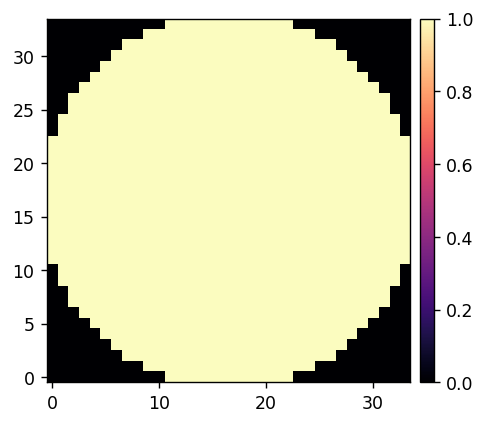

In [52]:
CAMLO_STREAM = ImageStream('camlo294')

DM_STREAMS = []
for i in range(1,6):
    DM_STREAMS.append(ImageStream(f'dm00disp{i:02}'))

rt_utils.create_shmim('llowfsc_zpo', (CAMLO_STREAM.shape[0], CAMLO_STREAM.shape[1]))
ZPO_STREAM = ImageStream('llowfsc_zpo')

rt_utils.create_shmim('llowfsc_gains', (10, 1))
GAINS_STREAM = ImageStream('llowfsc_gains')
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

Ncamlo = CAMLO_STREAM.shape[0]
Nact = DM_STREAMS[0].shape[0]

dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

In [44]:
def take_im_fun(
        CAMLO_STREAM,
        NFRAMES=1,
    ):
    camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0)
    # camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0) if NFRAMES>1 else CAMLO_STREAM.grab_after(1,0)[0]
    return camlo_im

take_im_params = {
    'CAMLO_STREAM':CAMLO_STREAM,
    'NFRAMES':1,
}

def set_dm_fun(
        command,
        DM_STREAM,
    ):

    DM_STREAM.write(1e6*ensure_np_array(command))

set_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}

def get_dm_fun(
        DM_STREAM,
    ):

    return 1e-6*DM_STREAM.grab_latest()


get_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}


def get_gains():
    return GAINS_STREAM.grab_latest()[0]



# Obtain a reference dark image for the camera settings that will be used during the duration of LLOWFSC.

In [ ]:
coro_utils.move_block_in(client0)

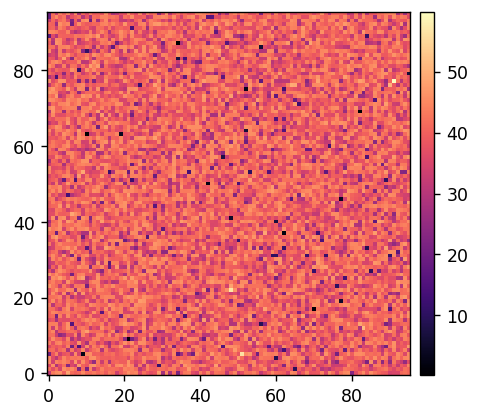

In [25]:

take_im_params.update({
    'NFRAMES':200,
})

camlo_dark = take_im_fun(**take_im_params)

utils.imshow([camlo_dark])

In [26]:
coro_utils.move_block_out(client0)

# Obtain the reference image.

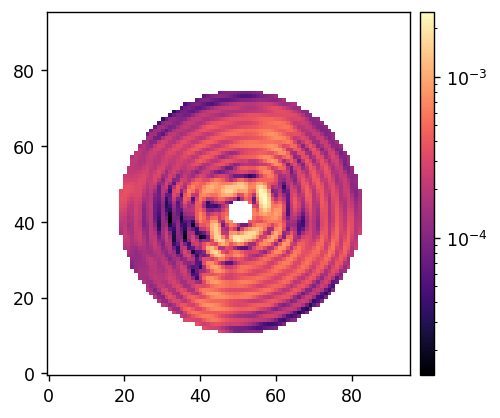

In [69]:
reload(llowfsc)

irad = 3
orad = 32
wfs_mask = utils.create_annular_focal_plane_mask(
    CAMLO_STREAM.shape[0], 
    1, 
    irad, 
    orad, 
    edge=None, 
    x_shift=3,
    y_shift=-5,
    centering='even', 
    return_np=1,
)

take_im_params.update({
    'NFRAMES':100,
})

ref_im, flux_norm_coeff = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    camlo_dark=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im],
    norms=[LogNorm()] 
)


# Calibrate for the set of Zernike modes that we want to control.

Calibrated mode 1/10 in 1.092s

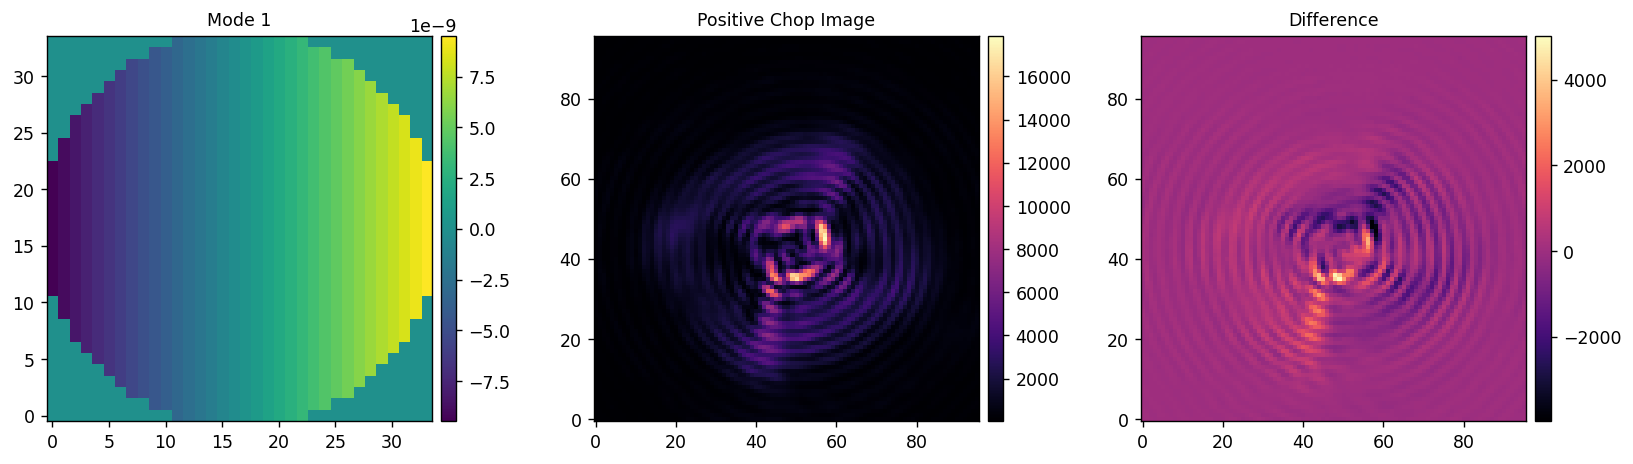

Calibrated mode 2/10 in 2.631s

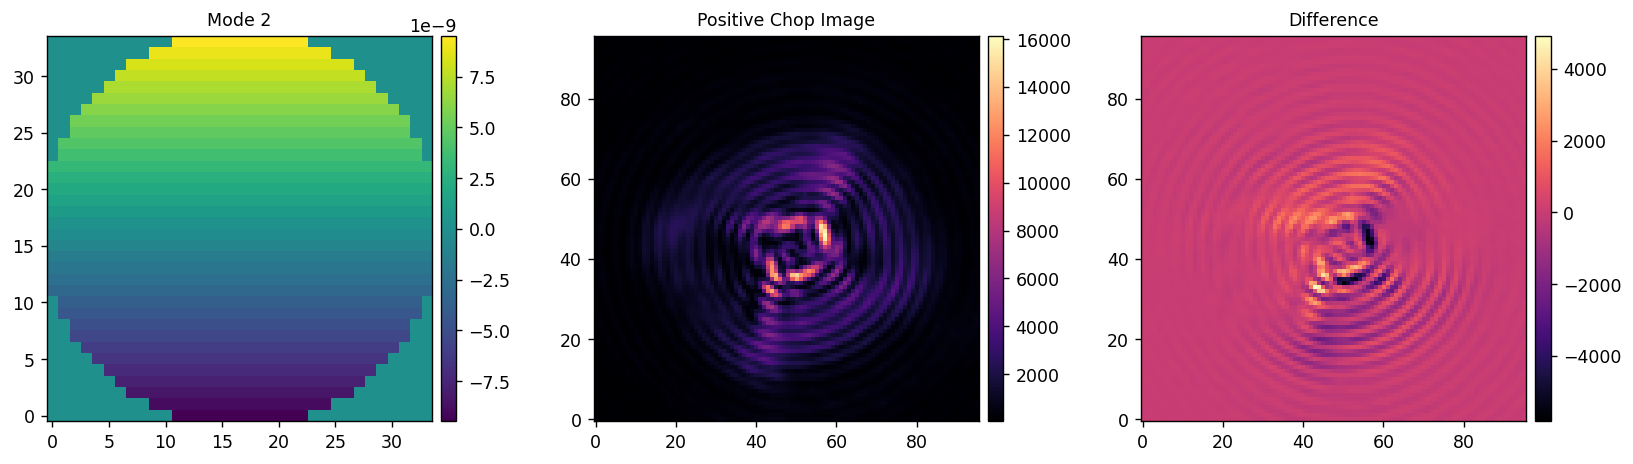

Calibrated mode 3/10 in 4.133s

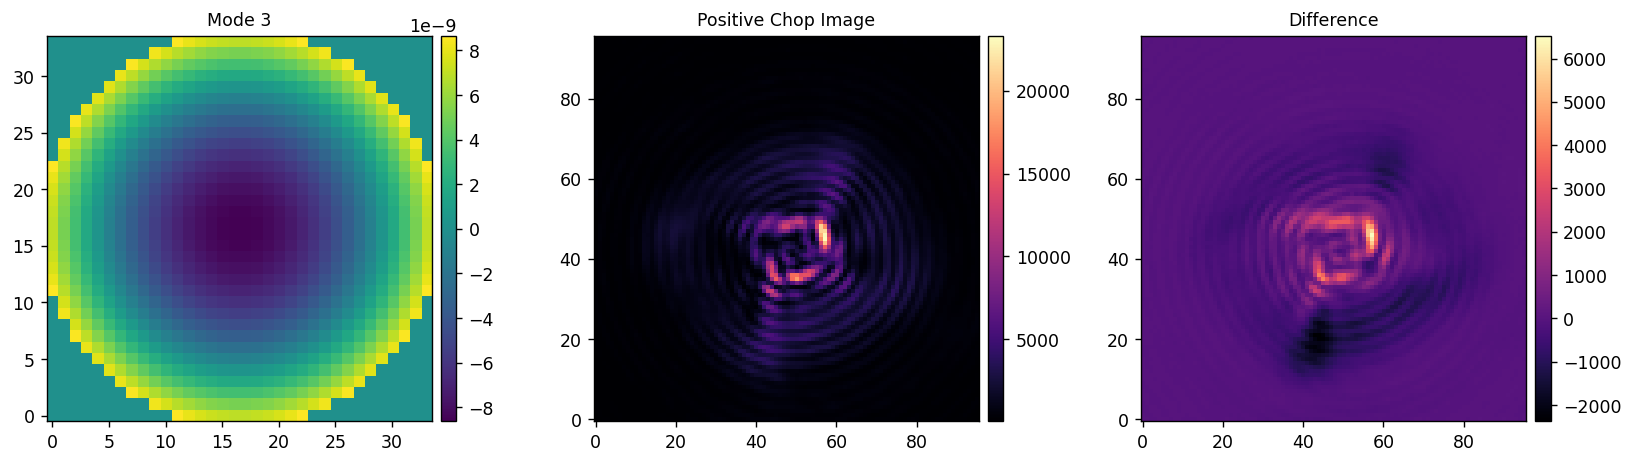

Calibrated mode 4/10 in 5.977s

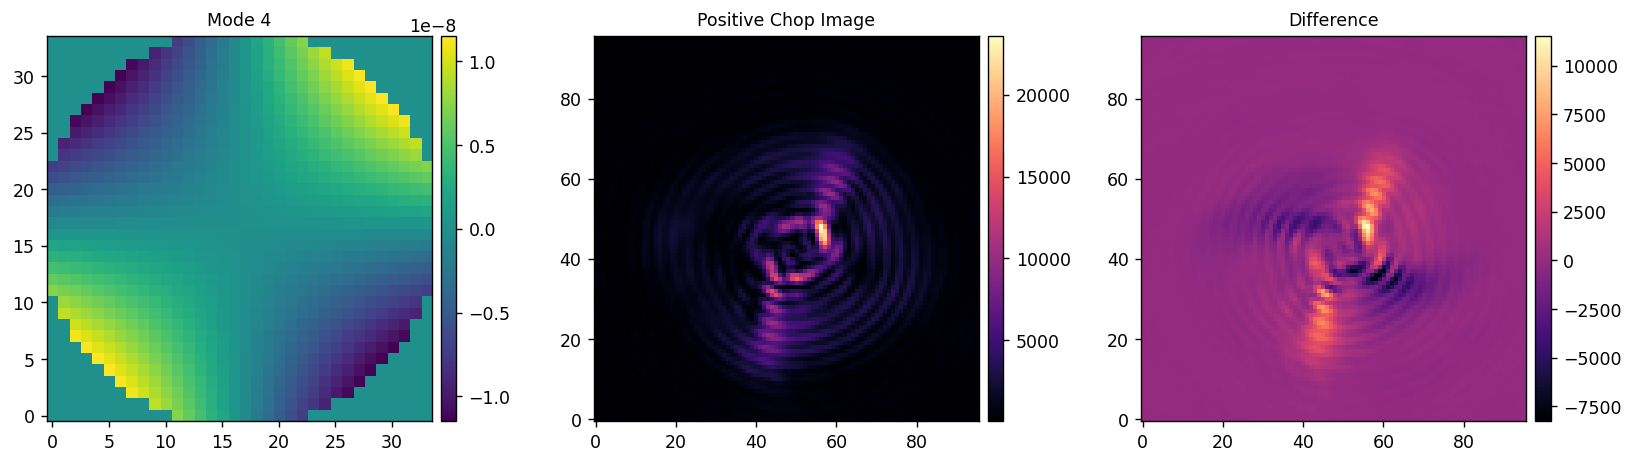

Calibrated mode 5/10 in 7.492s

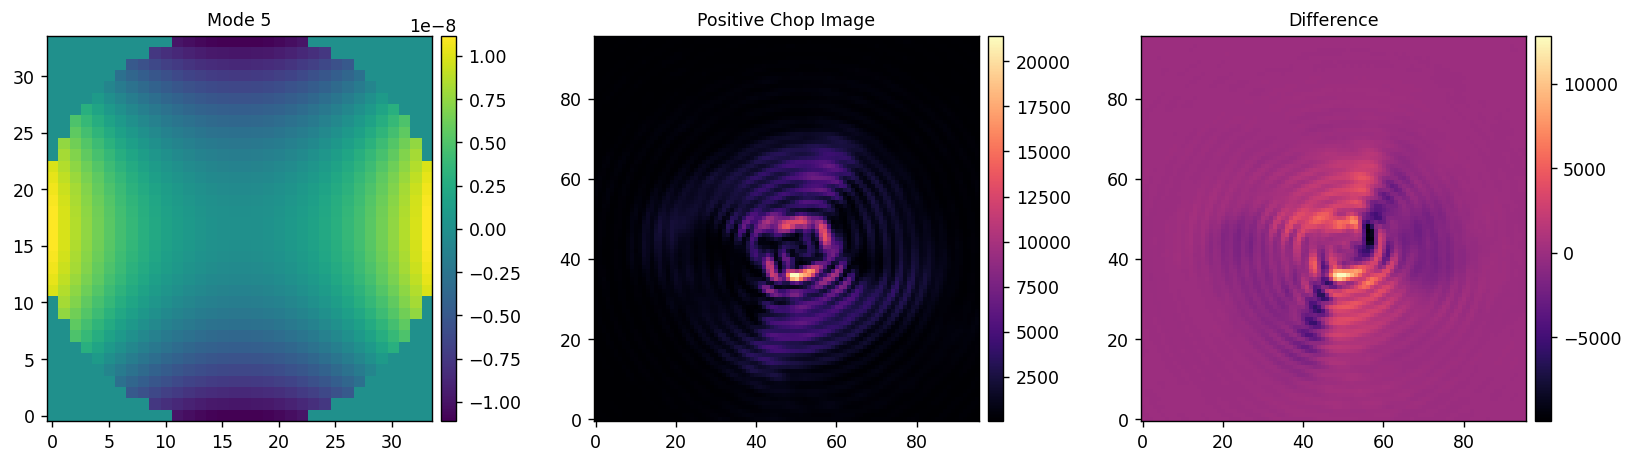

Calibrated mode 6/10 in 9.074s

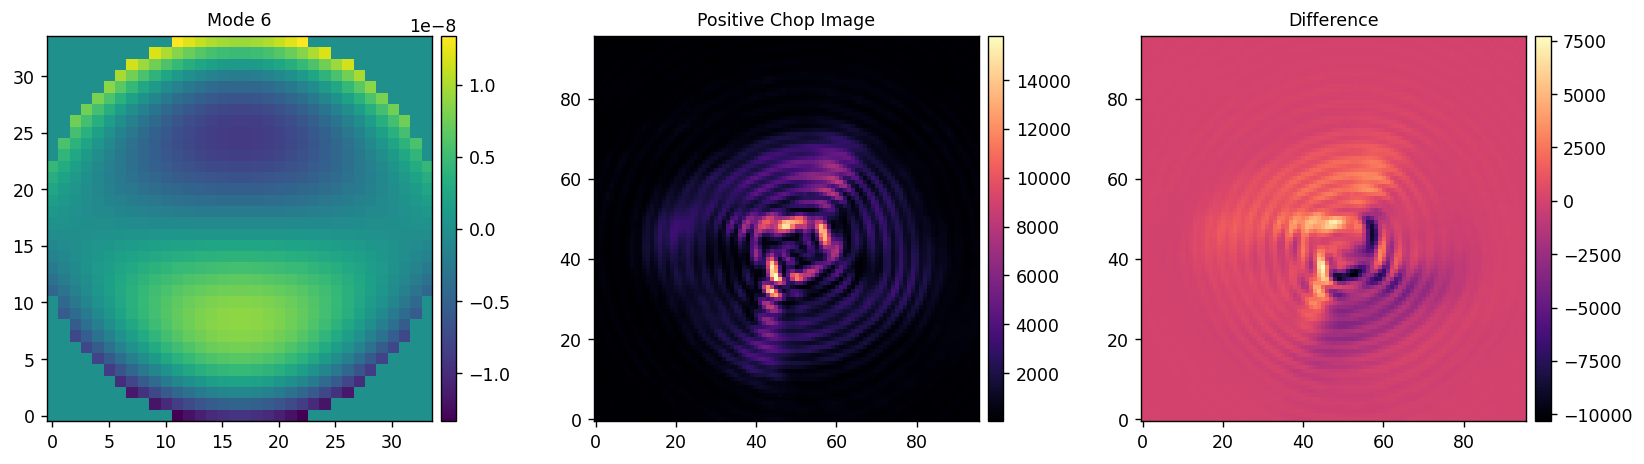

Calibrated mode 7/10 in 10.589s

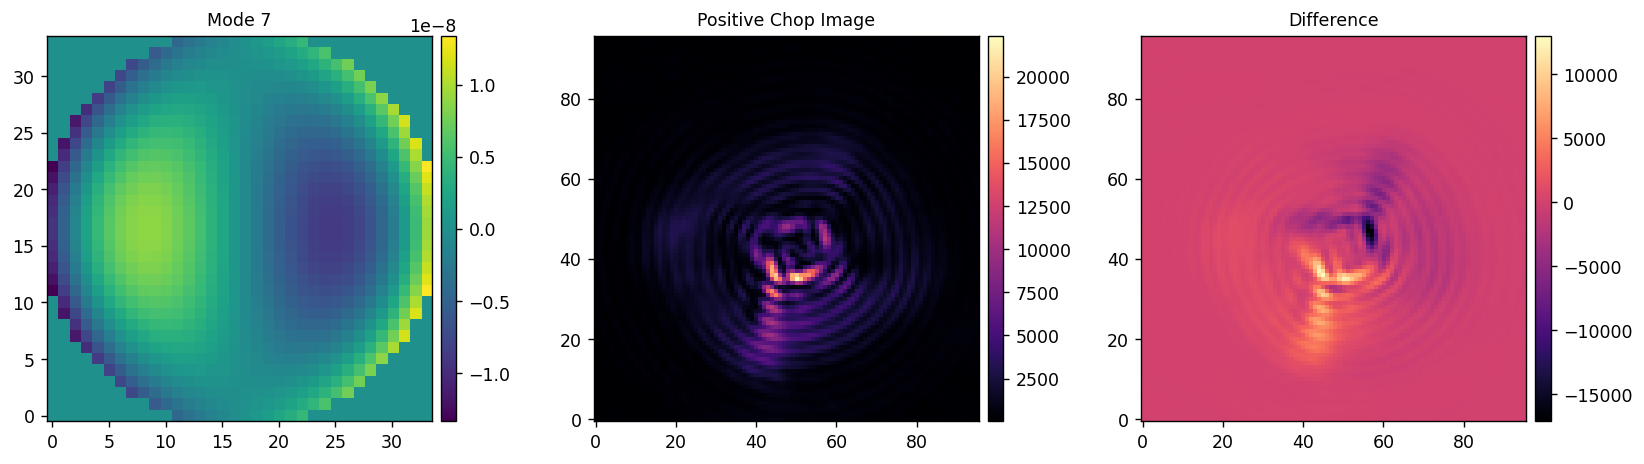

Calibrated mode 8/10 in 12.104s

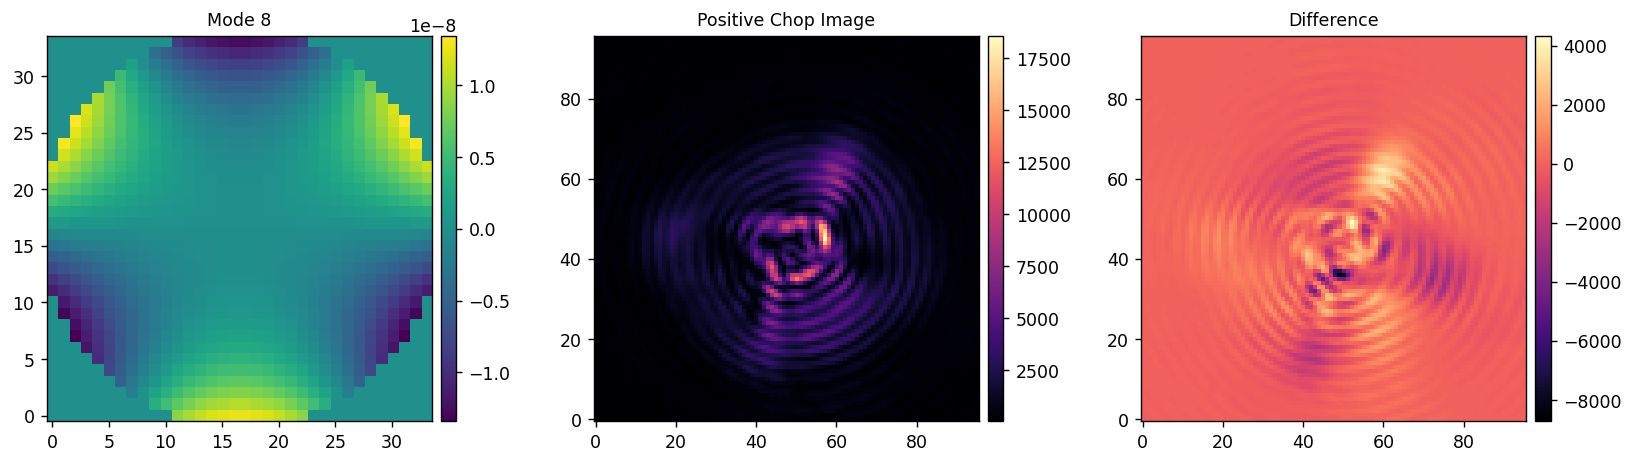

Calibrated mode 9/10 in 13.784s

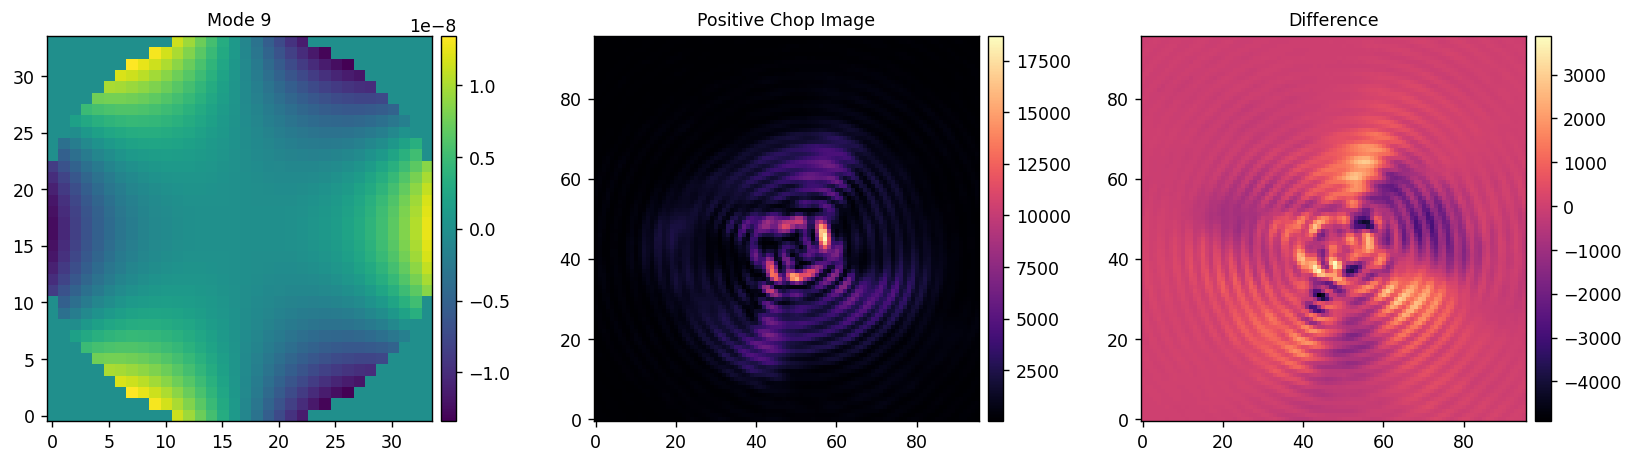

Calibrated mode 10/10 in 15.299s

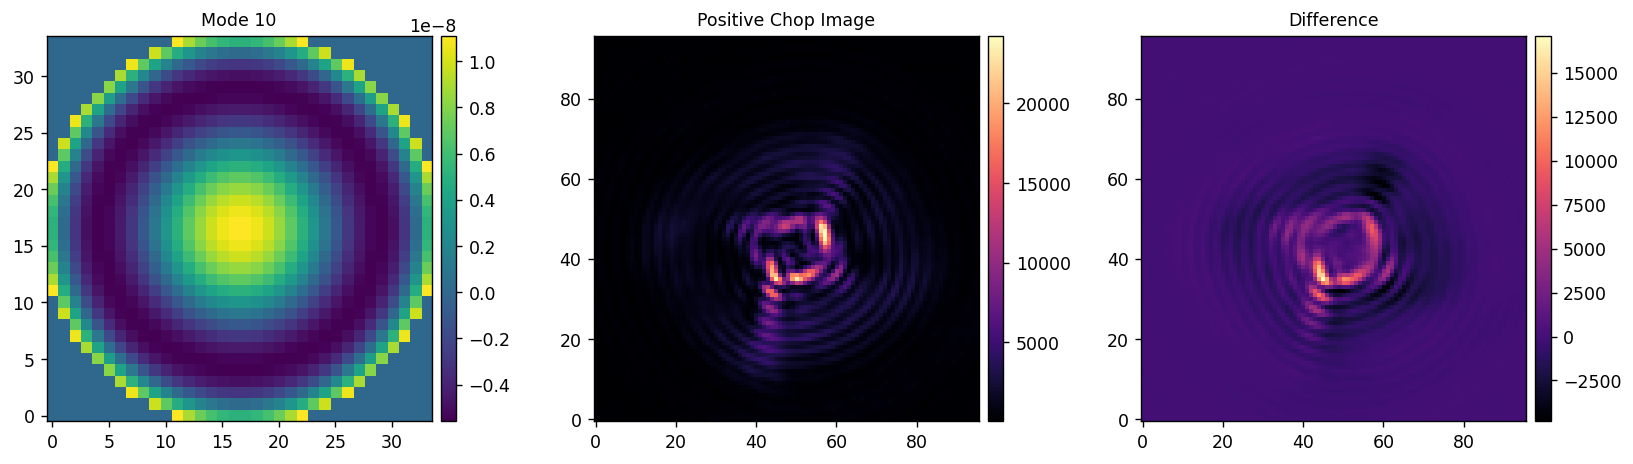

In [70]:
reload(llowfsc)
reload(dm)
reload(utils)

Nmodes = 10

dm_zer_mask = utils.pad_or_crop(dm.create_mask(Nact=Nact, return_np=1), DM_STREAMS[0].shape[0])
dm_zernike_modes = dm.create_zernike_modes(dm_zer_mask, nmodes=Nmodes, remove_modes=1, return_np=1)
# utils.imshow([dm_zernike_modes[0], dm_zernike_modes[3], dm_zernike_modes[-1]], cmaps=3*['viridis'])

take_im_params.update({
    'NFRAMES':50,
})

zer_rm, zer_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_zernike_modes, 
    wfs_mask, 
    amp=5e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    plot=True,
)


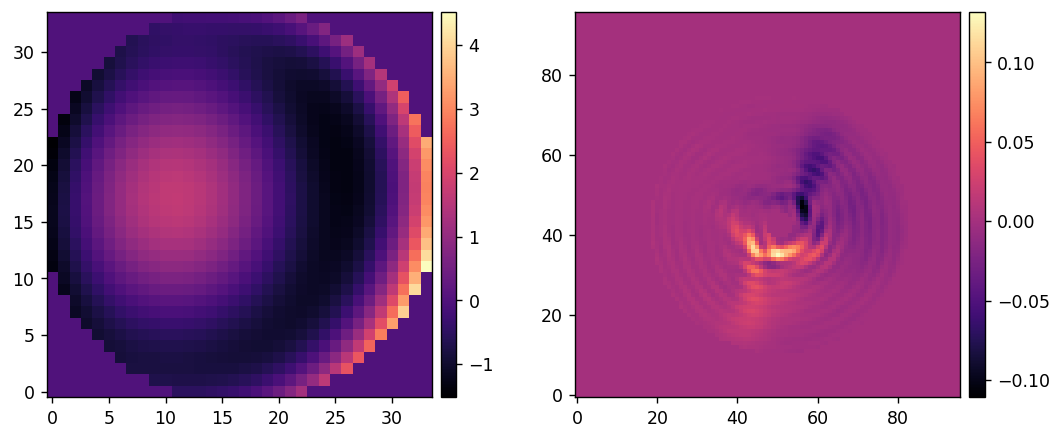

In [71]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(zer_rm, 0, return_all=1, return_np=1)

dm_modes = np.zeros((Nmodes, Nact, Nact))
wfs_modes = np.zeros((Nmodes, Ncamlo, Ncamlo))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(dm_zernike_modes[:, dm_mask])[i]
    # dm_modes[i, dm_mask] = Vt.T.dot(dm_zernike_modes[:, dm_mask])[i]
    wfs_modes[i, wfs_mask] = U.T[i] 

# dm_modes = Vt.dot(dm_zernike_modes[:, dm_mask])
# wfs_modes = U.T

# dm_modes.shape

i = 0
utils.imshow(
    [dm_modes[i], wfs_modes[i]]
)

In [72]:
reload(utils)
P = utils.tikhonov_inverse(zer_rm, 0, return_np=1)


In [74]:
def compute_zpo(
        DM_STREAMS,
        dm_mask,
        wfs_mask,
        response_matrix,
        dm_modal_matrix,
        ZPO_STREAM,
    ):
    zpo = np.zeros((wfs_mask.shape[0], wfs_mask.shape[1]))
    for i in range(len(DM_STREAMS)):
        zpo[wfs_mask] += response_matrix.dot( dm_modal_matrix.dot(DM_STREAMS[i].grab_latest()[dm_mask]) )

    ZPO_STREAM.write(zpo)

zpo_params = {
    # 'DM_STREAMS':DM_STREAMS[2:],
    'DM_STREAMS':[DM_STREAMS[2]],
    'dm_mask':dm_mask,
    'wfs_mask':wfs_mask,
    'response_matrix':zer_rm, 'dm_modal_matrix':dm_zernike_modes[:, dm_mask]/952,
    # 'response_matrix':had_rm, 'dm_modal_matrix':dm_had_modes[:, dm_mask]/1024,
    'ZPO_STREAM':ZPO_STREAM,
}

def get_zpo(ZPO_STREAM):
    return ZPO_STREAM.grab_latest()

get_zpo_params = {
    'ZPO_STREAM':ZPO_STREAM,
}

In [54]:
ZPO_STREAM.shape

(96, 96)

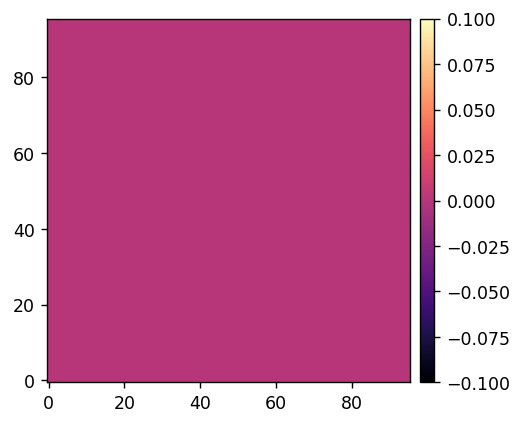

In [55]:
compute_zpo(**zpo_params)

zpo = ZPO_STREAM.grab_latest()

utils.imshow(
    [zpo]
)

In [56]:
%%timeit -n 1000
zpo = compute_zpo(**zpo_params)

47.6 μs ± 2.04 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [75]:
reload(llowfsc)
zpo_freq = 500

zpo_process = llowfsc.Process(
    1/zpo_freq,
    compute_zpo,
    kwargs=zpo_params,
)

In [76]:
zpo_process.start()

In [83]:
zpo_process.cancel()

In [60]:
DM_STREAMS[2].write(0e-9 * dm_zernike_modes[2])

In [77]:
import multiprocessing

take_im_params.update({
    'NFRAMES':1,
})

def run_llowfsc():
    while True:
        llowfsc.run(
            take_im_fun,
            take_im_params,
            set_dm_fun,
            set_dm_params,
            get_dm_fun,
            get_dm_params,
            get_gains,
            ref_im,
            P,
            dm_zernike_modes,
            wfs_mask,
            dark_im=camlo_dark,
            get_zpo=get_zpo,
            get_zpo_params=get_zpo_params,
        )

llowfsc_proc = multiprocessing.Process(target=run_llowfsc)


In [78]:
llowfsc_proc.start()
print(f'LLOWFSC process ID: {llowfsc_proc.pid}',)

LLOWFSC process ID: 1501301


In [82]:
llowfsc_proc.terminate()
set_dm_fun(np.zeros_like(dm_mask), **set_dm_params)

In [81]:
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.01]))